# Boosting Models — Ensemble Analysis vs LSTM

This notebook compares **individual boosting models**, all possible **ensemble combinations** of those models, and then pits the **best individual** and **best ensemble** boosting approach against the **LSTM model**.

## Supported Boosting Models
| Model Key | Algorithm | Status |
|-----------|-----------|--------|
| `xgboost` | XGBoost | Active (data available) |
| `catboost` | CatBoost | Enable in `config.py` → run pipeline |
| `lightgbm` | LightGBM | Enable in `config.py` → run pipeline |
| `gradient_boosting` | Gradient Boosting | Enable in `config.py` → run pipeline |
| `adaboost` | AdaBoost | Enable in `config.py` → run pipeline |

## How this notebook works
1. Loads `actual_forecast.csv` and **auto-detects** which boosting model columns are present.
2. Calculates KPIs for every **individual** boosting model.
3. Generates **every possible ensemble combination** (pairwise, triplets, all-models) using simple average and inverse-MAE weighted blending.
4. Ranks all individual models and all ensembles by MAE to find the **best of each type**.
5. Final 3-way comparison: **Best Individual Boosting vs Best Ensemble Boosting vs LSTM**.

## How to enable additional boosting models
1. Open `pipeline/config.py`
2. Uncomment the desired model entry in the `MODELS` dict (e.g., `catboost`, `lightgbm`)
3. Run the Lambda pipeline (or `plot_kpis.py` locally) to regenerate `actual_forecast.csv` and `daily_kpis.csv`
4. Re-run this notebook — additional models are picked up automatically

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ── Colour map for models (auto-extended if needed) ───────────────────────────
BASE_COLORS = [
    '#d62728',  # red      → xgboost
    '#ff7f0e',  # orange   → catboost
    '#9467bd',  # purple   → lightgbm
    '#8c564b',  # brown    → gradient_boosting
    '#e377c2',  # pink     → adaboost
]
LSTM_COLOR     = '#1f77b4'   # blue
ACTUAL_COLOR   = '#2ca02c'   # green
ENSEMBLE_COLOR = '#bcbd22'   # yellow-green (best ensemble)

print('Setup complete.')

Setup complete.


## 2. Load Data & Auto-Detect Boosting Models

In [2]:
BOOSTING_DATA_PATH = "KPI/boosting"
LSTM_DATA_PATH     = "KPI/lstm"

# Define comparison period: November 2025, December 2025, January 2026
COMPARISON_START = pd.Timestamp("2025-11-01")
COMPARISON_END   = pd.Timestamp("2026-01-31 23:59:59")

# Load boosting data (all active boosting models + lstm reference)
actual_forecast_raw  = pd.read_csv(f"{BOOSTING_DATA_PATH}/actual_forecast.csv", parse_dates=["datetime"])
daily_kpis_raw      = pd.read_csv(f"{BOOSTING_DATA_PATH}/daily_kpis.csv", parse_dates=["date"])
monthly_kpis_raw    = pd.read_csv(f"{BOOSTING_DATA_PATH}/monthly_kpis.csv")

# Load full LSTM history (all months) for the final 3-way comparison
lstm_af_raw = pd.read_csv(f"{LSTM_DATA_PATH}/actual_forecast.csv", parse_dates=["datetime"])
lstm_dk_raw = pd.read_csv(f"{LSTM_DATA_PATH}/daily_kpis.csv", parse_dates=["date"])

# Filter both datasets to comparison period (Nov 2025 - Jan 2026)
actual_forecast = actual_forecast_raw[
    (actual_forecast_raw['datetime'] >= COMPARISON_START) & 
    (actual_forecast_raw['datetime'] <= COMPARISON_END)
].copy()

lstm_af = lstm_af_raw[
    (lstm_af_raw['datetime'] >= COMPARISON_START) & 
    (lstm_af_raw['datetime'] <= COMPARISON_END)
].copy()

lstm_dk = lstm_dk_raw[
    (pd.to_datetime(lstm_dk_raw['date']) >= COMPARISON_START) & 
    (pd.to_datetime(lstm_dk_raw['date']) <= COMPARISON_END)
].copy()

daily_kpis_raw = daily_kpis_raw[
    (pd.to_datetime(daily_kpis_raw['date']) >= COMPARISON_START) & 
    (pd.to_datetime(daily_kpis_raw['date']) <= COMPARISON_END)
].copy()

# Auto-detect boosting model columns
BOOSTING_MODELS = [
    col.replace("_forecast", "")
    for col in actual_forecast.columns
    if col.endswith("_forecast") and col != "lstm_forecast"
]

print(f"Boosting data from       : {BOOSTING_DATA_PATH}")
print(f"LSTM data from           : {LSTM_DATA_PATH}")
print(f"Comparison period       : November 2025 - January 2026")
print(f"Detected boosting models : {BOOSTING_MODELS}")
print(f"LSTM present in boosting : {'lstm_forecast' in actual_forecast.columns}")
print(f"Boosting date range (filtered) : {actual_forecast['datetime'].min().date()} to "
      f"{actual_forecast['datetime'].max().date()}")
print(f"LSTM date range (filtered): {lstm_af['datetime'].min().date()} to "
      f"{lstm_af['datetime'].max().date()}")
print(f"Total boosting rows (filtered) : {len(actual_forecast)}")
print(f"Total LSTM rows (filtered)     : {len(lstm_af)}")
print()

if len(BOOSTING_MODELS) < 2:
    print("WARNING: Only ONE boosting model detected.")
    print("  Ensemble analysis requires >= 2 models.")
    print("  Enable additional models in pipeline/config.py and re-run.")
else:
    print(f"OK: {len(BOOSTING_MODELS)} boosting models -> all ensemble combinations will be generated.")

# Assign colours
MODEL_COLORS = {m: BASE_COLORS[i % len(BASE_COLORS)] for i, m in enumerate(BOOSTING_MODELS)}
MODEL_COLORS["lstm"] = LSTM_COLOR


Boosting data from       : KPI/boosting
LSTM data from           : KPI/lstm
Comparison period       : November 2025 - January 2026
Detected boosting models : ['xgboost', 'lightgbm', 'gradient_boosting', 'catboost', 'adaboost']
LSTM present in boosting : True
Boosting date range (filtered) : 2025-11-01 to 2026-01-31
LSTM date range (filtered): 2025-11-01 to 2026-01-31
Total boosting rows (filtered) : 4369
Total LSTM rows (filtered)     : 4369

OK: 5 boosting models -> all ensemble combinations will be generated.


## 3. KPI Calculation Helpers

In [3]:
def compute_kpis(actual: pd.Series, forecast: pd.Series) -> dict:
    """Compute MAE, RMSE, SMAPE between actual and forecast series."""
    mask  = actual.notna() & forecast.notna()
    a, f  = actual[mask], forecast[mask]
    if len(a) == 0:
        return {'mae': np.nan, 'rmse': np.nan, 'smape': np.nan, 'n': 0}
    err   = a - f
    denom = a.abs() + f.abs()
    smape = (200 * err.abs() / denom.replace(0, np.nan)).mean()
    return {
        'mae':   err.abs().mean(),
        'rmse':  np.sqrt((err**2).mean()),
        'smape': smape,
        'n':     len(a)
    }


def daily_kpis(df: pd.DataFrame, forecast_col: str) -> pd.DataFrame:
    """Compute daily MAE/RMSE/SMAPE for a single forecast column."""
    out = []
    for date, grp in df.groupby(df['datetime'].dt.date):
        kpi = compute_kpis(grp['actual_value'], grp[forecast_col])
        out.append({'date': pd.Timestamp(date), **kpi})
    return pd.DataFrame(out).set_index('date')


def ensemble_forecast(df: pd.DataFrame, models: list, weights=None) -> pd.Series:
    """Blend forecasts: simple average (weights=None) or weighted average."""
    cols = [f'{m}_forecast' for m in models]
    available = [c for c in cols if c in df.columns]
    sub = df[available].copy()
    if weights is None:
        return sub.mean(axis=1)
    w = np.array(weights[:len(available)])
    w = w / w.sum()
    return sub.multiply(w, axis=1).sum(axis=1)


def label_for(models: tuple, suffix='') -> str:
    """Human-readable label for an ensemble or individual model."""
    names = [m.replace('gradient_boosting', 'GBM').replace('_', '').upper() for m in models]
    base  = '+'.join(names)
    return f'Ensemble({base}){suffix}' if len(models) > 1 else names[0]


print('Helpers defined.')

Helpers defined.


## 4. Individual Boosting Model KPIs

In [4]:
individual_results = []
individual_daily   = {}

for model in BOOSTING_MODELS:
    col = f'{model}_forecast'
    if col not in actual_forecast.columns:
        print(f'  ⚠ {model}: column not found, skipping.')
        continue
    monthly = compute_kpis(actual_forecast['actual_value'], actual_forecast[col])
    daily   = daily_kpis(actual_forecast, col)
    individual_daily[model] = daily
    individual_results.append({
        'Model':   label_for((model,)),
        'Type':    'Individual',
        'Models':  (model,),
        'MAE':     round(monthly['mae'],   4),
        'RMSE':    round(monthly['rmse'],  4),
        'SMAPE':   round(monthly['smape'], 4),
        'N':       monthly['n'],
    })

individual_df = pd.DataFrame(individual_results).sort_values('MAE').reset_index(drop=True)
print('=== Individual Boosting Model KPIs (Nov 2025 - Jan 2026) ===')
display(individual_df[['Model', 'MAE', 'RMSE', 'SMAPE', 'N']])

=== Individual Boosting Model KPIs (Nov 2025 - Jan 2026) ===


,Model,MAE,RMSE,SMAPE,N
0,GBM,1.5208,2.1535,14.2977,3745
1,LIGHTGBM,1.5214,2.1851,14.3529,3745
2,XGBOOST,1.5298,2.1401,14.3555,3745
3,CATBOOST,1.7178,2.3893,16.0890,3745
4,ADABOOST,1.7183,2.2717,16.7094,3745


## 5. Generate All Ensemble Combinations

In [5]:
ensemble_results = []
ensemble_daily   = {}

if len(BOOSTING_MODELS) < 2:
    print('Skipping ensemble generation — need ≥ 2 boosting models.')
    print('Enable additional models in pipeline/config.py and re-run the Lambda pipeline.')
else:
    # ── Build individual model MAE weights for inverse-MAE ensemble ───────────
    ind_mae = {r['Models'][0]: r['MAE'] for r in individual_results}

    # ── Generate all subsets of size 2 … N ───────────────────────────────────
    available_models = [m for m in BOOSTING_MODELS if f'{m}_forecast' in actual_forecast.columns]

    for size in range(2, len(available_models) + 1):
        for combo in combinations(available_models, size):

            # --- Simple average ensemble ---
            fc_avg = ensemble_forecast(actual_forecast, list(combo))
            kpi_avg = compute_kpis(actual_forecast['actual_value'], fc_avg)
            lbl_avg = label_for(combo, '-Avg')
            daily_avg = []
            for date, grp in actual_forecast.groupby(actual_forecast['datetime'].dt.date):
                fc_d = ensemble_forecast(grp.reset_index(drop=True), list(combo))
                k    = compute_kpis(grp['actual_value'].reset_index(drop=True), fc_d)
                daily_avg.append({'date': pd.Timestamp(date), **k})
            ensemble_daily[lbl_avg] = pd.DataFrame(daily_avg).set_index('date')

            ensemble_results.append({
                'Model':  lbl_avg,
                'Type':   f'Ensemble-{size}model-Avg',
                'Models': combo,
                'MAE':    round(kpi_avg['mae'],   4),
                'RMSE':   round(kpi_avg['rmse'],  4),
                'SMAPE':  round(kpi_avg['smape'], 4),
                'N':      kpi_avg['n'],
            })

            # --- Inverse-MAE weighted ensemble ---
            w_raw = [1.0 / max(ind_mae.get(m, 1e-6), 1e-6) for m in combo]
            fc_wt  = ensemble_forecast(actual_forecast, list(combo), weights=w_raw)
            kpi_wt = compute_kpis(actual_forecast['actual_value'], fc_wt)
            lbl_wt = label_for(combo, '-WtAvg')
            daily_wt = []
            for date, grp in actual_forecast.groupby(actual_forecast['datetime'].dt.date):
                fc_d = ensemble_forecast(grp.reset_index(drop=True), list(combo), weights=w_raw)
                k    = compute_kpis(grp['actual_value'].reset_index(drop=True), fc_d)
                daily_wt.append({'date': pd.Timestamp(date), **k})
            ensemble_daily[lbl_wt] = pd.DataFrame(daily_wt).set_index('date')

            ensemble_results.append({
                'Model':  lbl_wt,
                'Type':   f'Ensemble-{size}model-WtAvg',
                'Models': combo,
                'MAE':    round(kpi_wt['mae'],   4),
                'RMSE':   round(kpi_wt['rmse'],  4),
                'SMAPE':  round(kpi_wt['smape'], 4),
                'N':      kpi_wt['n'],
            })

    ensemble_df = pd.DataFrame(ensemble_results).sort_values('MAE').reset_index(drop=True)
    print(f'Generated {len(ensemble_df)} ensemble variants.')
    print('=== All Ensemble KPIs (sorted by MAE) ===')
    display(ensemble_df[['Model', 'Type', 'MAE', 'RMSE', 'SMAPE']])

Generated 52 ensemble variants.
=== All Ensemble KPIs (sorted by MAE) ===


,Model,Type,MAE,RMSE,SMAPE
0,Ensemble(XGBOOST+LIGHTGBM+ADABOOST)-Avg,Ensemble-3model-Avg,1.4093,2.0095,13.4596
1,Ensemble(XGBOOST+LIGHTGBM+GBM+ADABOOST)-Avg,Ensemble-4model-Avg,1.4101,2.0131,13.4377
2,Ensemble(XGBOOST+LIGHTGBM+CATBOOST+ADABOOST)-Avg,Ensemble-4model-Avg,1.4130,2.0312,13.4847
3,Ensemble(XGBOOST+LIGHTGBM+GBM+CATBOOST+ADABOOS...,Ensemble-5model-Avg,1.4139,2.0285,13.4783
4,Ensemble(XGBOOST+GBM+CATBOOST+ADABOOST)-Avg,Ensemble-4model-Avg,1.4172,2.0307,13.5049
5,Ensemble(LIGHTGBM+GBM+CATBOOST+ADABOOST)-Avg,Ensemble-4model-Avg,1.4210,2.0325,13.5702
6,Ensemble(XGBOOST+GBM+ADABOOST)-Avg,Ensemble-3model-Avg,1.4228,2.0176,13.5638
7,Ensemble(XGBOOST+CATBOOST+ADABOOST)-Avg,Ensemble-3model-Avg,1.4251,2.0439,13.5830
8,Ensemble(LIGHTGBM+GBM+ADABOOST)-Avg,Ensemble-3model-Avg,1.4264,2.0139,13.6487
9,Ensemble(GBM+CATBOOST+ADABOOST)-Avg,Ensemble-3model-Avg,1.4323,2.0428,13.6698


## 6. Rank All Boosting Approaches

In [6]:
# Combine individual + ensemble into a single leaderboard
all_rows = individual_results.copy()
if ensemble_results:
    all_rows += ensemble_results

leaderboard = pd.DataFrame(all_rows).sort_values('MAE').reset_index(drop=True)
leaderboard.index += 1   # rank starts at 1

print('=== Complete Boosting Leaderboard (Individuals + Ensembles, sorted by MAE) ===')
display(leaderboard[['Model', 'Type', 'MAE', 'RMSE', 'SMAPE']])

# ── Select champions ─────────────────────────────────────────────────────────
best_individual_row = individual_df.iloc[0]
BEST_INDIVIDUAL_KEY = best_individual_row['Models'][0]
BEST_INDIVIDUAL_LBL = best_individual_row['Model']

if ensemble_results:
    best_ensemble_row  = ensemble_df.iloc[0]
    BEST_ENSEMBLE_LBL  = best_ensemble_row['Model']
    BEST_ENSEMBLE_MODELS = list(best_ensemble_row['Models'])
    # Reconstruct the ensemble weight type from label
    use_weighted = 'WtAvg' in BEST_ENSEMBLE_LBL
    if use_weighted:
        ind_mae = {r['Models'][0]: r['MAE'] for r in individual_results}
        best_ensemble_weights = [1.0 / max(ind_mae.get(m, 1e-6), 1e-6) for m in BEST_ENSEMBLE_MODELS]
    else:
        best_ensemble_weights = None
else:
    best_ensemble_row = None
    BEST_ENSEMBLE_LBL = None

print(f'\n>>> Best Individual Boosting : {BEST_INDIVIDUAL_LBL}  (MAE={best_individual_row["MAE"]})')
if BEST_ENSEMBLE_LBL:
    print(f'>>> Best Ensemble Boosting   : {BEST_ENSEMBLE_LBL}  (MAE={best_ensemble_row["MAE"]})')

=== Complete Boosting Leaderboard (Individuals + Ensembles, sorted by MAE) ===


,Model,Type,MAE,RMSE,SMAPE
1,Ensemble(XGBOOST+LIGHTGBM+ADABOOST)-Avg,Ensemble-3model-Avg,1.4093,2.0095,13.4596
2,Ensemble(XGBOOST+LIGHTGBM+GBM+ADABOOST)-Avg,Ensemble-4model-Avg,1.4101,2.0131,13.4377
3,Ensemble(XGBOOST+LIGHTGBM+CATBOOST+ADABOOST)-Avg,Ensemble-4model-Avg,1.4130,2.0312,13.4847
4,Ensemble(XGBOOST+LIGHTGBM+GBM+CATBOOST+ADABOOS...,Ensemble-5model-Avg,1.4139,2.0285,13.4783
5,Ensemble(XGBOOST+GBM+CATBOOST+ADABOOST)-Avg,Ensemble-4model-Avg,1.4172,2.0307,13.5049
6,Ensemble(LIGHTGBM+GBM+CATBOOST+ADABOOST)-Avg,Ensemble-4model-Avg,1.4210,2.0325,13.5702
7,Ensemble(XGBOOST+GBM+ADABOOST)-Avg,Ensemble-3model-Avg,1.4228,2.0176,13.5638
8,Ensemble(XGBOOST+CATBOOST+ADABOOST)-Avg,Ensemble-3model-Avg,1.4251,2.0439,13.5830
9,Ensemble(LIGHTGBM+GBM+ADABOOST)-Avg,Ensemble-3model-Avg,1.4264,2.0139,13.6487
10,Ensemble(GBM+CATBOOST+ADABOOST)-Avg,Ensemble-3model-Avg,1.4323,2.0428,13.6698



>>> Best Individual Boosting : GBM  (MAE=1.5208)
>>> Best Ensemble Boosting   : Ensemble(XGBOOST+LIGHTGBM+ADABOOST)-Avg  (MAE=1.4093)


## 7. Leaderboard Bar Chart — All Boosting Approaches

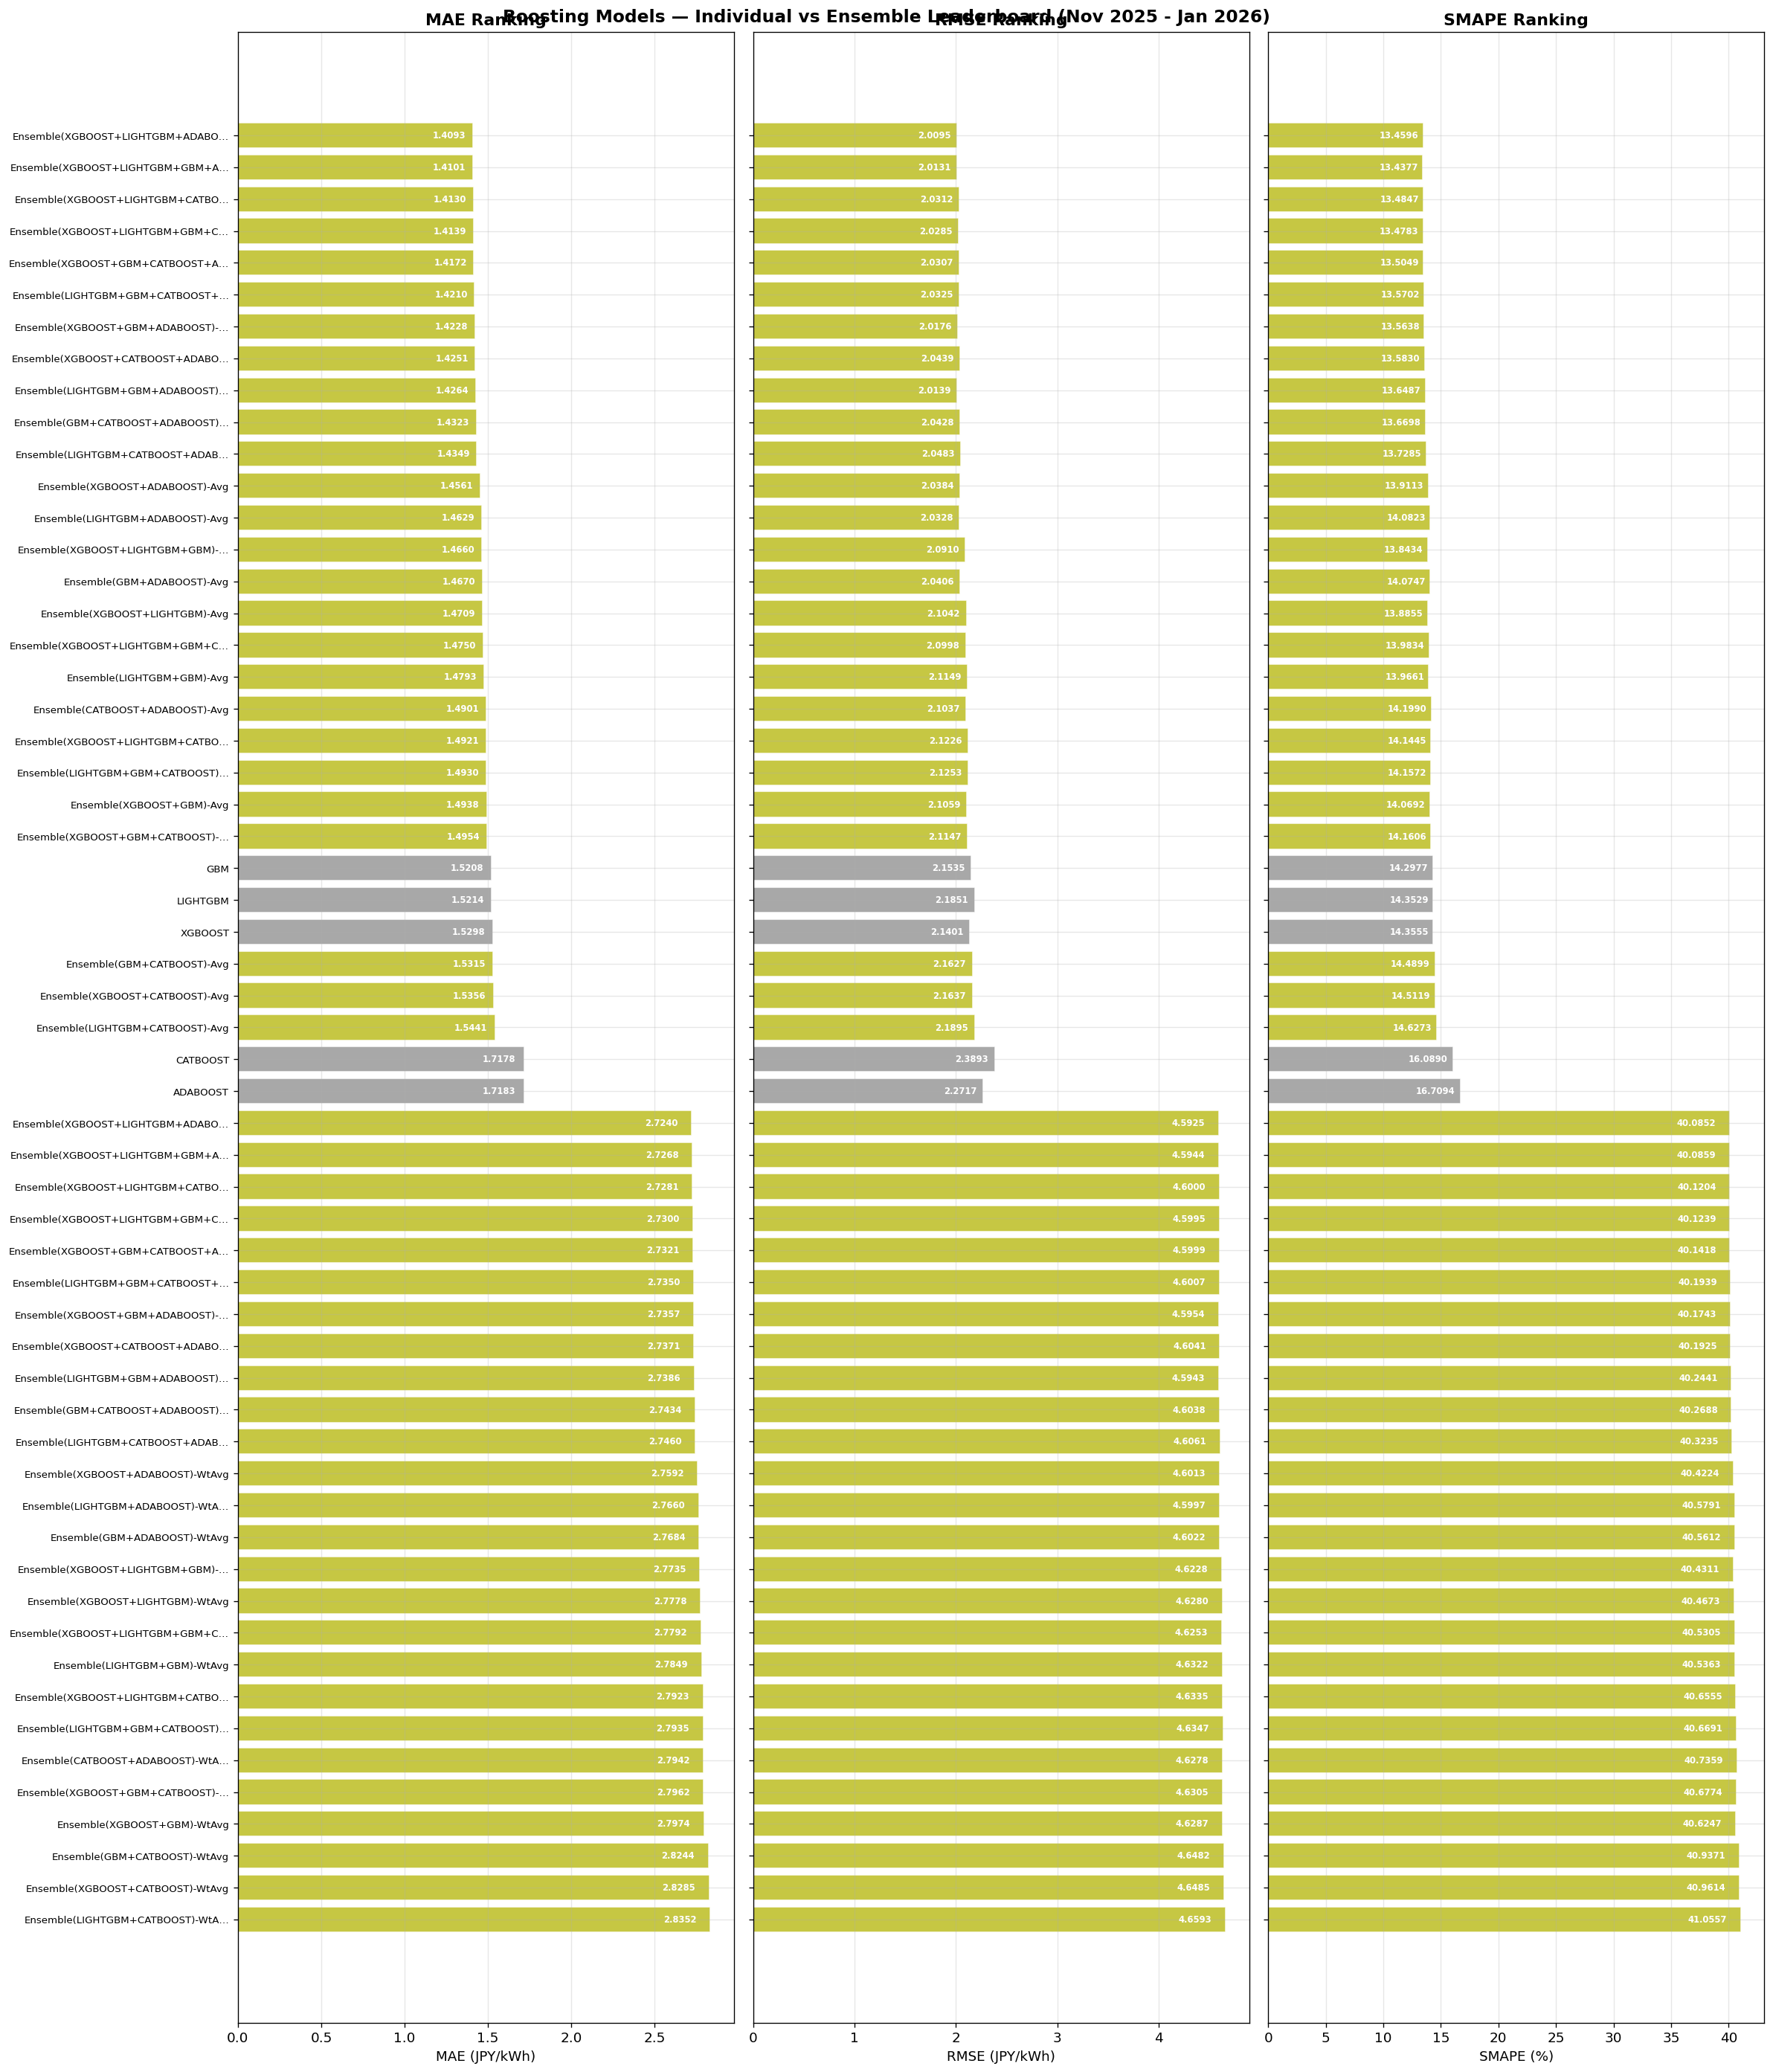

Plot saved.


In [7]:

# ── Short labels for y-axis (first subplot only) ─────────────────────────────
def shorten_label(name, max_chars=32):
    return name if len(name) <= max_chars else name[:max_chars - 1] + '…'

short_labels = [shorten_label(n) for n in leaderboard['Model']]
y_pos = list(range(len(leaderboard)))

fig, axes = plt.subplots(1, 3, figsize=(20, max(5, len(leaderboard) * 0.38 + 2)),
                          sharey=True)
metrics    = ['MAE', 'RMSE', 'SMAPE']
metric_lbl = ['MAE (JPY/kWh)', 'RMSE (JPY/kWh)', 'SMAPE (%)']

for i, (ax, metric, lbl) in enumerate(zip(axes, metrics, metric_lbl)):
    colors = [
        ENSEMBLE_COLOR if 'Ensemble' in r else MODEL_COLORS.get(r.lower(), '#999')
        for r in leaderboard['Type']
    ]
    vals = leaderboard[metric]
    max_val = vals.max(skipna=True)

    bars = ax.barh(y_pos, vals, color=colors, alpha=0.85, edgecolor='white')

    # Value labels inside bars — right-aligned, white text
    for bar, val in zip(bars, vals):
        if pd.notna(val) and val > 0:
            ax.text(val * 0.97, bar.get_y() + bar.get_height() / 2,
                    f'{val:.4f}', va='center', ha='right',
                    fontsize=7, color='white', fontweight='bold')

    # y-axis labels: show model names only on the first (leftmost) subplot
    ax.set_yticks(y_pos)
    if i == 0:
        ax.set_yticklabels(short_labels, fontsize=8)
    else:
        ax.tick_params(labelleft=False)

    ax.invert_yaxis()
    ax.set_xlabel(lbl)
    ax.set_title(f'{metric} Ranking', fontweight='bold')
    ax.set_xlim(0, max_val * 1.05)

fig.suptitle('Boosting Models — Individual vs Ensemble Leaderboard (Nov 2025 - Jan 2026)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('KPI/boosting_leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')


## 8. Daily KPI for Every Boosting Approach

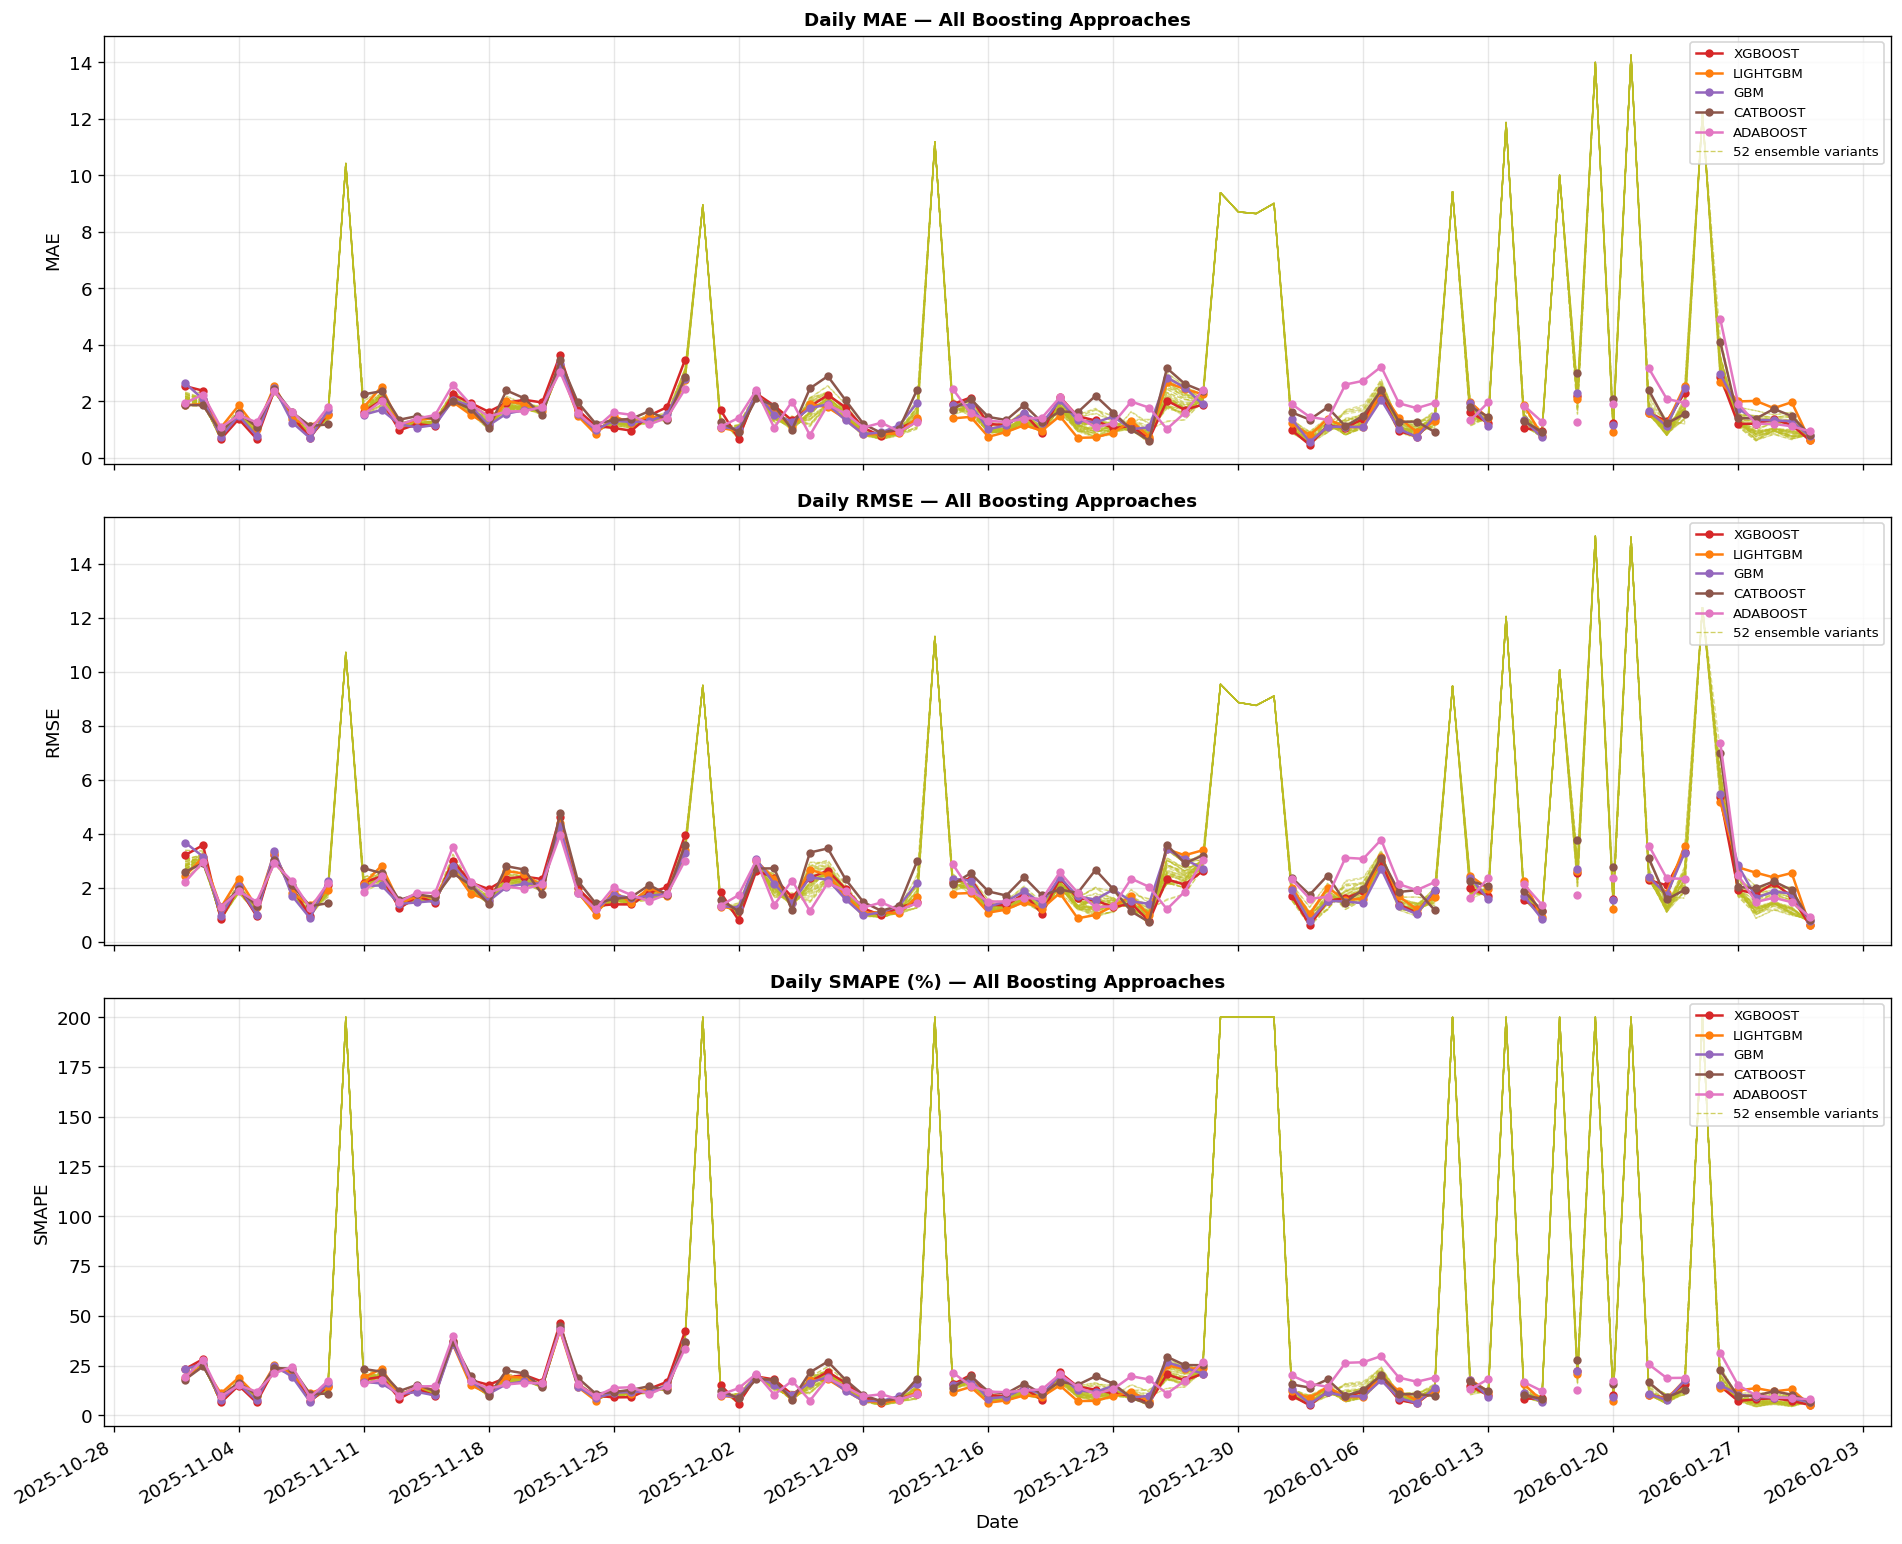

Plot saved.


In [8]:

from matplotlib.lines import Line2D

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)
metrics = ['mae', 'rmse', 'smape']
titles  = ['Daily MAE — All Boosting Approaches',
           'Daily RMSE — All Boosting Approaches',
           'Daily SMAPE (%) — All Boosting Approaches']

for ax, m, title in zip(axes, metrics, titles):
    # Individual models — shown in legend
    for model, daily in individual_daily.items():
        ax.plot(daily.index, daily[m],
                label=label_for((model,)),
                color=MODEL_COLORS.get(model, '#999'),
                linewidth=1.5, linestyle='solid', marker='o', markersize=4, zorder=3)

    # Ensemble models — not individually labelled (too many entries)
    for ens_lbl, daily in ensemble_daily.items():
        ax.plot(daily.index, daily[m],
                linewidth=0.8, linestyle='--', alpha=0.45, color='#bcbd22')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(m.upper())

    # Build compact legend: individual models + one placeholder for all ensembles
    handles, labels_leg = ax.get_legend_handles_labels()
    ens_line = Line2D([0], [0], color='#bcbd22', linewidth=0.8,
                      linestyle='--', alpha=0.7)
    ax.legend(handles=handles + [ens_line],
              labels=labels_leg + [f'{len(ensemble_daily)} ensemble variants'],
              fontsize=8, loc='upper right')

axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('KPI/boosting_all_approaches_daily.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')


## 9. Final 3-Way Comparison: Best Individual vs Best Ensemble vs LSTM

In [9]:
# ── Build forecast series for the champions ───────────────────────────────────
af = actual_forecast.copy()

af['best_individual_fc'] = af[f'{BEST_INDIVIDUAL_KEY}_forecast']

if BEST_ENSEMBLE_LBL and best_ensemble_row is not None:
    af['best_ensemble_fc'] = ensemble_forecast(
        af, BEST_ENSEMBLE_MODELS,
        weights=best_ensemble_weights if use_weighted else None
    )
    has_ensemble = True
else:
    has_ensemble = False
    print('No ensemble available — showing individual vs LSTM only.')

# ── Build comparison frame ────────────────────────────────────────────────────
competitors = {
    f'Best Individual ({BEST_INDIVIDUAL_LBL})': 'best_individual_fc',
    'LSTM': 'lstm_forecast',
}
if has_ensemble:
    competitors = {
        f'Best Individual ({BEST_INDIVIDUAL_LBL})': 'best_individual_fc',
        f'Best Ensemble ({BEST_ENSEMBLE_LBL})':     'best_ensemble_fc',
        'LSTM':                                      'lstm_forecast',
    }

comp_colors = {
    f'Best Individual ({BEST_INDIVIDUAL_LBL})': MODEL_COLORS.get(BEST_INDIVIDUAL_KEY, '#d62728'),
    f'Best Ensemble ({BEST_ENSEMBLE_LBL})':     ENSEMBLE_COLOR,
    'LSTM':                                      LSTM_COLOR,
}

print('Competitor forecasts prepared.')

Competitor forecasts prepared.


In [10]:
# ── Monthly KPI comparison table ─────────────────────────────────────────────
rows = []
for name, col in competitors.items():
    if col not in af.columns:
        continue
    kpi = compute_kpis(af['actual_value'], af[col])
    rows.append({'Model': name, 'MAE': round(kpi['mae'],4),
                 'RMSE': round(kpi['rmse'],4), 'SMAPE%': round(kpi['smape'],4)})

comp_monthly = pd.DataFrame(rows).set_index('Model')
print('=== Monthly KPI — Final 3-Way Comparison (Nov 2025 - Jan 2026) ===')
display(comp_monthly)

print('\nWinner by metric (lower is better):')
for col in comp_monthly.columns:
    winner = comp_monthly[col].idxmin()
    margin = comp_monthly[col].max() - comp_monthly[col].min()
    print(f'  {col:8s}: {winner}  (margin = {margin:.4f})')

=== Monthly KPI — Final 3-Way Comparison (Nov 2025 - Jan 2026) ===


,MAE,RMSE,SMAPE%
Model,,,
Best Individual (GBM),1.5208,2.1535,14.2977
Best Ensemble (Ensemble(XGBOOST+LIGHTGBM+ADABOOST)-Avg),1.4093,2.0095,13.4596
LSTM,1.3760,2.0449,13.2274



Winner by metric (lower is better):
  MAE     : LSTM  (margin = 0.1448)
  RMSE    : Best Ensemble (Ensemble(XGBOOST+LIGHTGBM+ADABOOST)-Avg)  (margin = 0.1440)
  SMAPE%  : LSTM  (margin = 1.0703)


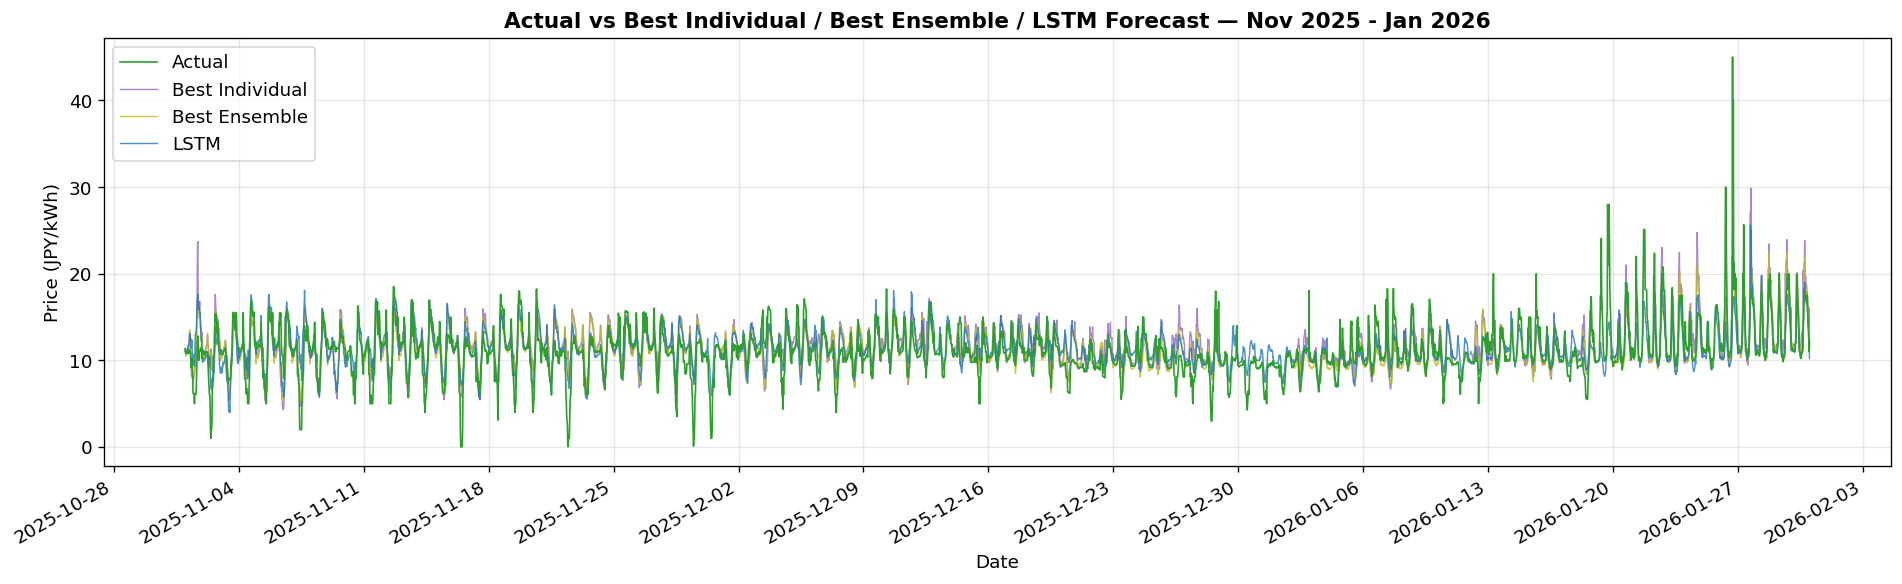

Plot saved.


In [11]:

# ── Actual vs all three forecasts timeline ────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(af['datetime'], af['actual_value'],
        label='Actual', color=ACTUAL_COLOR, linewidth=1.0, zorder=4)

for name, col in competitors.items():
    if col in af.columns:
        short_name = name.split('(')[0].strip()   # e.g. "Best Individual", "Best Ensemble", "LSTM"
        ax.plot(af['datetime'], af[col],
                label=short_name, color=comp_colors.get(name, '#999'),
                linewidth=0.85, alpha=0.8)

ax.set_title('Actual vs Best Individual / Best Ensemble / LSTM Forecast — Nov 2025 - Jan 2026',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (JPY/kWh)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
fig.autofmt_xdate()
ax.legend()
plt.tight_layout()
plt.savefig('KPI/final_comparison_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')


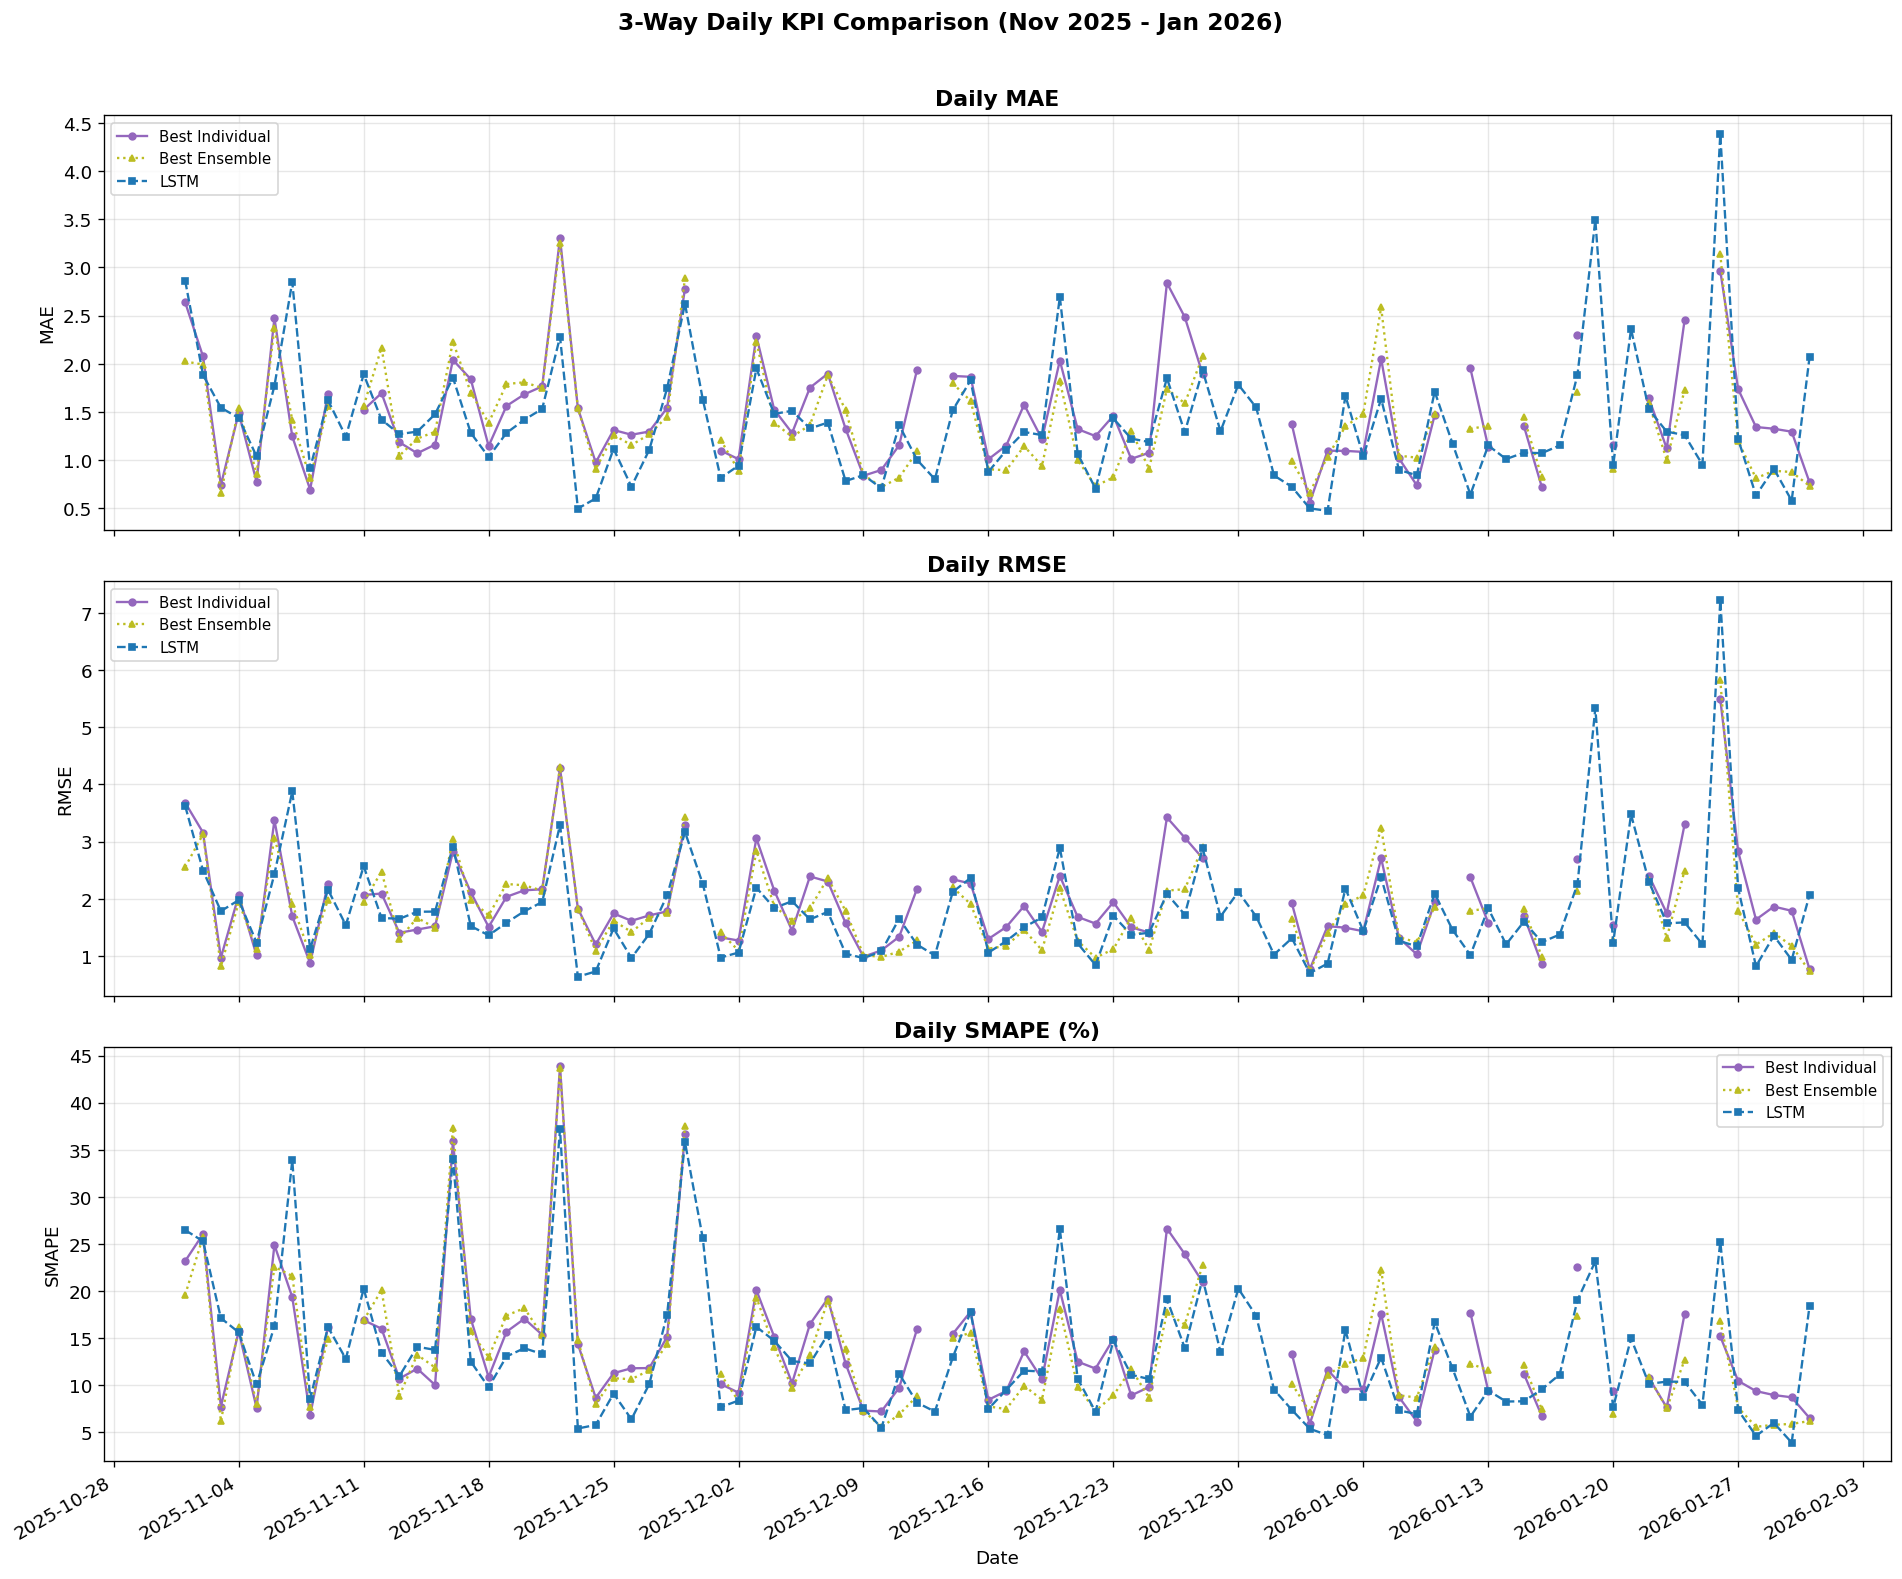

Plot saved.


In [12]:

# ── Daily KPI comparison — 3-way ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)
metric_list = ['mae', 'rmse', 'smape']
title_list  = ['Daily MAE', 'Daily RMSE', 'Daily SMAPE (%)']

# Build per-competitor daily series
comp_daily = {}
for name, col in competitors.items():
    if col not in af.columns:
        continue
    rows = []
    for date, grp in af.groupby(af['datetime'].dt.date):
        k = compute_kpis(grp['actual_value'], grp[col])
        rows.append({'date': pd.Timestamp(date), **k})
    comp_daily[name] = pd.DataFrame(rows).set_index('date')

for ax, m, t in zip(axes, metric_list, title_list):
    for name, daily in comp_daily.items():
        short_name = name.split('(')[0].strip()   # "Best Individual", "Best Ensemble", "LSTM"
        style = {'linestyle': '--', 'marker': 's', 'markersize': 4} if name == 'LSTM' else \
                {'linestyle': ':', 'marker': '^', 'markersize': 4} if 'Ensemble' in name else \
                {'linestyle': '-', 'marker': 'o', 'markersize': 4}
        ax.plot(daily.index, daily[m],
                label=short_name, color=comp_colors.get(name, '#999'),
                linewidth=1.4, **style)
    ax.set_title(t, fontweight='bold')
    ax.set_ylabel(m.upper())
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
fig.autofmt_xdate()
fig.suptitle('3-Way Daily KPI Comparison (Nov 2025 - Jan 2026)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('KPI/final_comparison_daily_kpis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')


## 10. Win-Rate Analysis — Day-by-Day

=== Daily Win-Rate (by MAE, 92 overlap days) ===
  (LSTM full history: 92 days across all periods)
  Best Individual (GBM)                        : 15 days (16.3%)
  Best Ensemble (Ensemble(XGBOOST+LIGHTGBM+ADABOOST)-Avg): 24 days (26.1%)
  LSTM                                         : 53 days (57.6%)


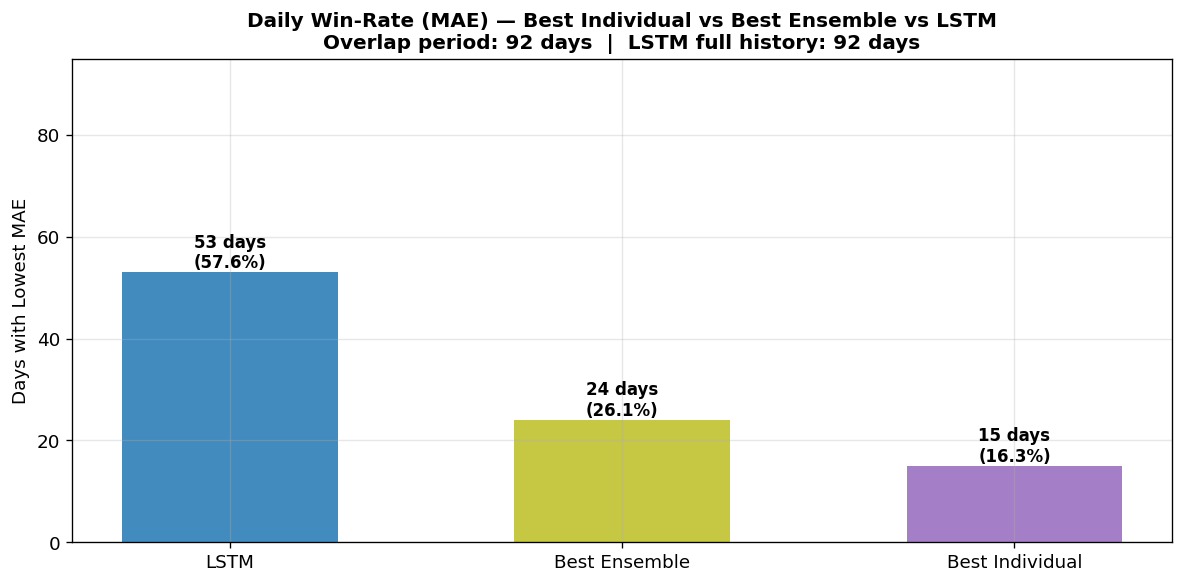

Plot saved.


In [13]:
# Build daily MAE frame for all competitors (overlap / boosting period)
daily_mae_df = pd.DataFrame({name: d["mae"] for name, d in comp_daily.items()})

# Winner each day = column with lowest MAE
daily_mae_df["winner"] = daily_mae_df.idxmin(axis=1)

win_counts = daily_mae_df["winner"].value_counts()
total_days = daily_mae_df["winner"].notna().sum()   # overlap (boosting) period

# LSTM full history context (3 months)
lstm_total_days = lstm_dk["date"].nunique()

print(f"=== Daily Win-Rate (by MAE, {total_days} overlap days) ===")
print(f"  (LSTM full history: {lstm_total_days} days across all periods)")
for name in competitors:
    wins = win_counts.get(name, 0)
    pct  = wins / total_days * 100 if total_days > 0 else 0
    print(f"  {name:45s}: {wins:2d} days ({pct:.1f}%)")

# Plot win-rate
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    [n.split("(")[0].strip() for n in win_counts.index],
    win_counts.values,
    color=[comp_colors.get(n, "#999") for n in win_counts.index],
    alpha=0.85, width=0.55
)
for bar, val in zip(bars, win_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val} days\n({val/total_days*100:.1f}%)",
            ha="center", va="bottom", fontweight="bold", fontsize=10)
ax.set_title(
    f"Daily Win-Rate (MAE) — Best Individual vs Best Ensemble vs LSTM\n"
    f"Overlap period: {total_days} days  |  LSTM full history: {lstm_total_days} days",
    fontsize=12, fontweight="bold"
)
ax.set_ylabel("Days with Lowest MAE")
ax.set_ylim(0, total_days + 3)
plt.tight_layout()
plt.savefig("KPI/final_comparison_win_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

## 11. Error Distribution Comparison

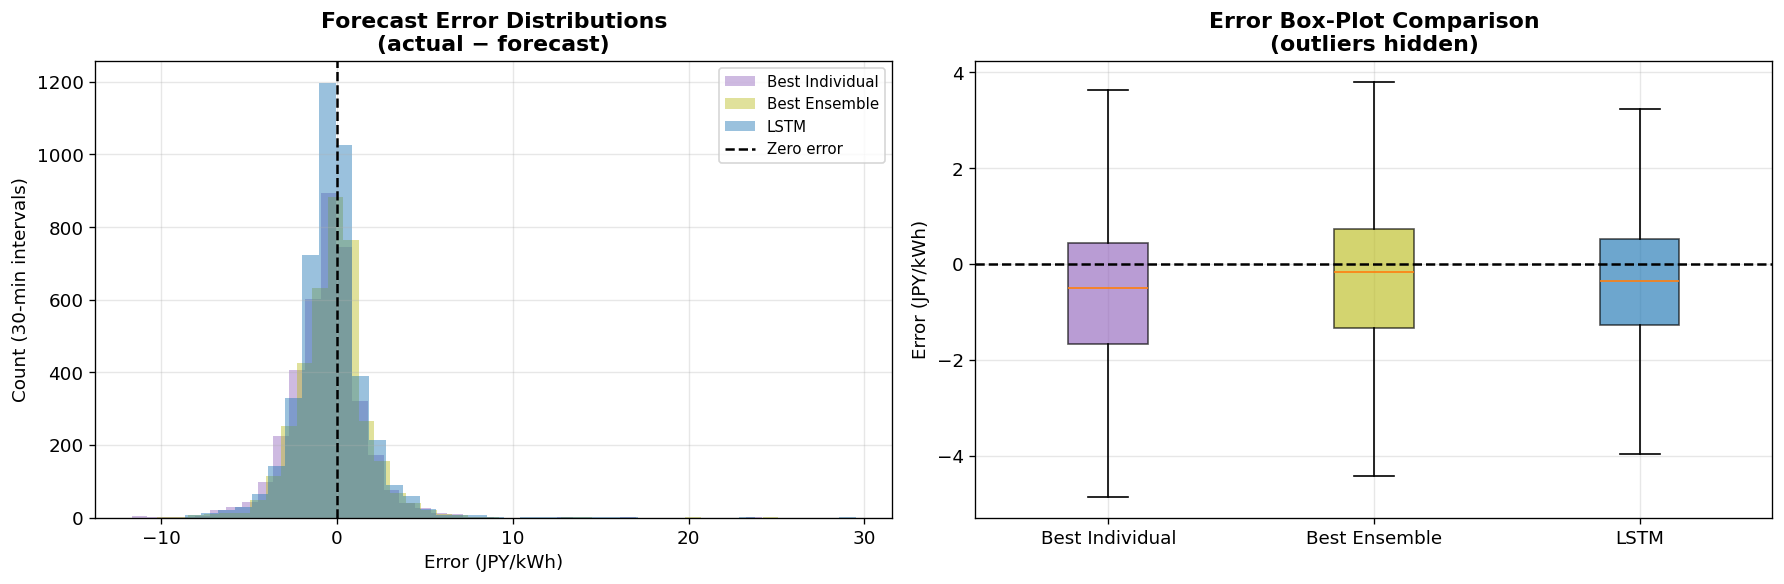

Plot saved.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Overlapping error histograms ─────────────────────────────────────────────
ax = axes[0]
for name, col in competitors.items():
    if col not in af.columns:
        continue
    err = (af['actual_value'] - af[col]).dropna()
    ax.hist(err, bins=40, alpha=0.45, label=name.split('(')[0].strip(),
            color=comp_colors.get(name, '#999'))
ax.axvline(0, color='black', linewidth=1.5, linestyle='--', label='Zero error')
ax.set_title('Forecast Error Distributions\n(actual − forecast)', fontweight='bold')
ax.set_xlabel('Error (JPY/kWh)')
ax.set_ylabel('Count (30-min intervals)')
ax.legend(fontsize=9)

# ── Box plot ─────────────────────────────────────────────────────────────────
ax = axes[1]
box_data   = []
box_labels = []
box_colors = []
for name, col in competitors.items():
    if col not in af.columns:
        continue
    err = (af['actual_value'] - af[col]).dropna()
    box_data.append(err.values)
    box_labels.append(name.split('(')[0].strip())
    box_colors.append(comp_colors.get(name, '#999'))

bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_title('Error Box-Plot Comparison\n(outliers hidden)', fontweight='bold')
ax.set_ylabel('Error (JPY/kWh)')

plt.tight_layout()
plt.savefig('KPI/final_comparison_error_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 12. Ensemble Improvement Over Best Individual

In [15]:
if has_ensemble:
    ind_mae  = best_individual_row['MAE']
    ens_mae  = best_ensemble_row['MAE']
    lstm_mae = comp_monthly.loc['LSTM', 'MAE'] if 'LSTM' in comp_monthly.index else np.nan

    ind_smape  = best_individual_row['SMAPE']
    ens_smape  = best_ensemble_row['SMAPE']
    lstm_smape = comp_monthly.loc['LSTM', 'SMAPE%'] if 'LSTM' in comp_monthly.index else np.nan

    print('=== Ensemble Improvement Analysis ===')
    print(f'  Best Individual MAE  : {ind_mae:.4f}')
    print(f'  Best Ensemble MAE    : {ens_mae:.4f}')
    mae_gain = (ind_mae - ens_mae) / ind_mae * 100 if ind_mae > 0 else 0
    print(f'  MAE improvement      : {mae_gain:+.2f}% ({"Ensemble better" if ens_mae < ind_mae else "Individual better"})')
    print()
    print(f'  Best Individual SMAPE: {ind_smape:.4f}%')
    print(f'  Best Ensemble SMAPE  : {ens_smape:.4f}%')
    smape_gain = (ind_smape - ens_smape) / ind_smape * 100 if ind_smape > 0 else 0
    print(f'  SMAPE improvement    : {smape_gain:+.2f}%')
    print()
    if not np.isnan(lstm_mae):
        winner_vs_lstm = 'Ensemble' if ens_mae < lstm_mae else 'LSTM'
        gap = abs(ens_mae - lstm_mae)
        print(f'  Best Ensemble MAE vs LSTM: {ens_mae:.4f} vs {lstm_mae:.4f}  → {winner_vs_lstm} wins (margin={gap:.4f})')
else:
    print('Enable ≥ 2 boosting models to see ensemble improvement analysis.')
    print('Currently showing single-model (XGBoost) vs LSTM only.')

=== Ensemble Improvement Analysis ===
  Best Individual MAE  : 1.5208
  Best Ensemble MAE    : 1.4093
  MAE improvement      : +7.33% (Ensemble better)

  Best Individual SMAPE: 14.2977%
  Best Ensemble SMAPE  : 13.4596%
  SMAPE improvement    : +5.86%

  Best Ensemble MAE vs LSTM: 1.4093 vs 1.3760  → LSTM wins (margin=0.0333)


## 13. Radar Chart — 3-Way KPI Comparison

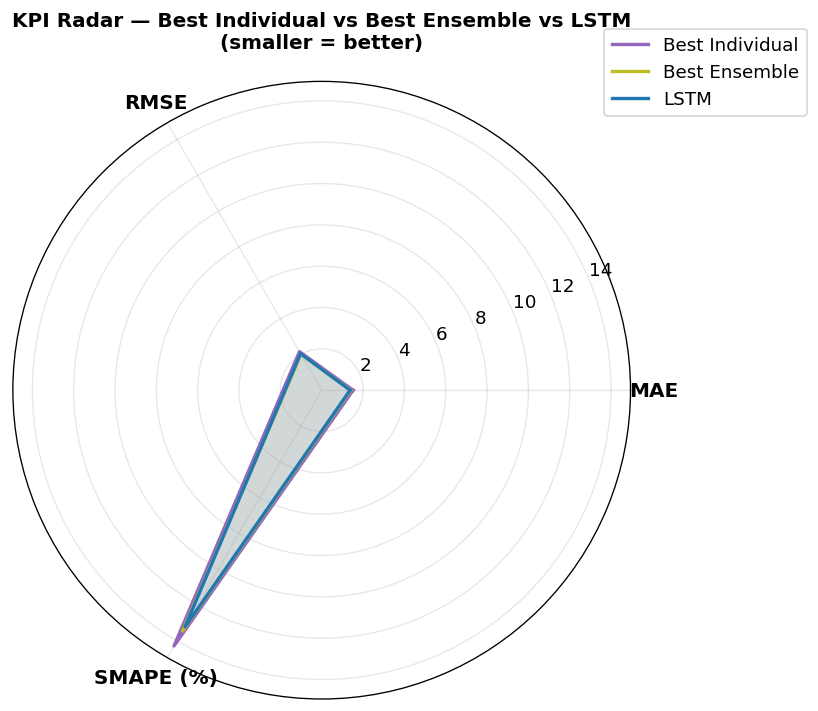

Plot saved.


In [16]:
categories = ['MAE', 'RMSE', 'SMAPE (%)']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})

for name, col in competitors.items():
    if col not in af.columns:
        continue
    kpi = compute_kpis(af['actual_value'], af[col])
    vals = [kpi['mae'], kpi['rmse'], kpi['smape']]
    vals += vals[:1]
    color = comp_colors.get(name, '#999')
    ax.plot(angles, vals, color=color, linewidth=2, label=name.split('(')[0].strip())
    ax.fill(angles, vals, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_title('KPI Radar — Best Individual vs Best Ensemble vs LSTM\n(smaller = better)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('KPI/final_comparison_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 14. Final Summary

In [17]:
print('=' * 70)
print('  BOOSTING ENSEMBLE ANALYSIS — FINAL SUMMARY')
print('  Period: November 2025 - January 2026 | Area: Tohoku')
print('=' * 70)
print(f'  Boosting models detected   : {len(BOOSTING_MODELS)}')
print(f'  Models                     : {", ".join(BOOSTING_MODELS)}')
if ensemble_results:
    print(f'  Ensemble variants tested   : {len(ensemble_df)}')
print()
print(f'  Best Individual Boosting   : {BEST_INDIVIDUAL_LBL}')
print(f'    MAE   : {best_individual_row["MAE"]:.4f}')
print(f'    RMSE  : {best_individual_row["RMSE"]:.4f}')
print(f'    SMAPE : {best_individual_row["SMAPE"]:.4f}%')
print()
if BEST_ENSEMBLE_LBL:
    print(f'  Best Ensemble Boosting     : {BEST_ENSEMBLE_LBL}')
    print(f'    Models : {", ".join(BEST_ENSEMBLE_MODELS)}')
    print(f'    MAE    : {best_ensemble_row["MAE"]:.4f}')
    print(f'    RMSE   : {best_ensemble_row["RMSE"]:.4f}')
    print(f'    SMAPE  : {best_ensemble_row["SMAPE"]:.4f}%')
    print()
print('  LSTM (reference):')
if 'LSTM' in comp_monthly.index:
    print(f'    MAE   : {comp_monthly.loc["LSTM", "MAE"]:.4f}')
    print(f'    RMSE  : {comp_monthly.loc["LSTM", "RMSE"]:.4f}')
    print(f'    SMAPE : {comp_monthly.loc["LSTM", "SMAPE%"]:.4f}%')
print()
print('  Final KPI Table:')
display(comp_monthly)
print('=' * 70)
print('  NOTE: Enable additional boosting models in pipeline/config.py')
print('  and re-run the pipeline to include CatBoost, LightGBM, etc.')
print('  All ensemble combinations are computed automatically.')
print('=' * 70)

  BOOSTING ENSEMBLE ANALYSIS — FINAL SUMMARY
  Period: November 2025 - January 2026 | Area: Tohoku
  Boosting models detected   : 5
  Models                     : xgboost, lightgbm, gradient_boosting, catboost, adaboost
  Ensemble variants tested   : 52

  Best Individual Boosting   : GBM
    MAE   : 1.5208
    RMSE  : 2.1535
    SMAPE : 14.2977%

  Best Ensemble Boosting     : Ensemble(XGBOOST+LIGHTGBM+ADABOOST)-Avg
    Models : xgboost, lightgbm, adaboost
    MAE    : 1.4093
    RMSE   : 2.0095
    SMAPE  : 13.4596%

  LSTM (reference):
    MAE   : 1.3760
    RMSE  : 2.0449
    SMAPE : 13.2274%

  Final KPI Table:


,MAE,RMSE,SMAPE%
Model,,,
Best Individual (GBM),1.5208,2.1535,14.2977
Best Ensemble (Ensemble(XGBOOST+LIGHTGBM+ADABOOST)-Avg),1.4093,2.0095,13.4596
LSTM,1.3760,2.0449,13.2274


  NOTE: Enable additional boosting models in pipeline/config.py
  and re-run the pipeline to include CatBoost, LightGBM, etc.
  All ensemble combinations are computed automatically.
